<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 7, Chronos-2**

Chronos-2 es un foundation model para series de tiempo: viene entrenado con
millones de series y pronostica una serie nueva sin entrenar nada. Lo que lo hace distinto de todo lo que vimos hasta ahora: su salida nativa no es un número, son cuantiles.

Datos: demanda diaria de bicicletas (Capital Bikeshare, 2011–2012).

---

## 1. Instalamos y cargamos Chronos-2

In [ ]:
!pip install -q "chronos-forecasting>=2.0"

In [ ]:
import torch, pandas as pd, matplotlib.pyplot as plt
from chronos import Chronos2Pipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=device)

## 2. El formato que espera

Formato largo, tres columnas:

| columna | qué es | nombre por defecto |
|---|---|---|
| identificador de la serie | qué serie es cada fila | `item_id` |
| tiempo | la fecha | `timestamp` |
| valor | lo que querés pronosticar | `target` |

Si tus columnas se llaman distinto, se lo podemos decir por parámetro. No hace falta renombrar nada.

Los timestamps tienen que ser regulares y sin huecos. Si te faltan días, rellenalos primero."""


In [ ]:
URL = ("https://raw.githubusercontent.com/udacity/deep-learning-v2-pytorch/master/project-bikesharing/Bike-Sharing-Dataset/day.csv")
raw = pd.read_csv(URL, parse_dates=["dteday"])

df = (raw.rename(columns={"dteday": "timestamp", "cnt": "target"})
         .assign(item_id="bicis")[["item_id", "timestamp", "target"]])

df.tail(3)


## 3. Uso básico

Una llamada. Le pasás los datos y cuántos pasos querés hacia adelante.

In [ ]:
pred = pipe.predict_df(df, prediction_length=14)
pred

,item_id,timestamp,target_name,predictions,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,bicis,2013-01-01,target,3085.561035,1551.792725,2102.145020,2485.958496,2802.416992,3085.561035,3352.209961,3612.996094,3915.003418,4326.033203
1,bicis,2013-01-02,target,3413.347656,1541.552246,2195.897949,2666.354248,3061.783203,3413.347656,3750.479492,4073.124023,4434.916992,4897.933105
2,bicis,2013-01-03,target,3645.809570,1613.259277,2339.645020,2850.134766,3271.378174,3645.809570,4004.197754,4342.594727,4711.815430,5174.931641
3,bicis,2013-01-04,target,3775.208496,1640.045166,2397.199951,2927.370361,3374.911133,3775.208496,4151.460938,4495.404785,4860.240234,5302.778320
4,bicis,2013-01-05,target,3788.648193,1595.296875,2397.326416,2947.917969,3394.906982,3788.648193,4159.623047,4504.324219,4882.779785,5354.323242
5,bicis,2013-01-06,target,3761.481201,1555.778564,2352.786865,2899.964844,3356.505615,3761.481201,4146.113281,4503.790039,4895.236816,5366.116699
6,bicis,2013-01-07,target,3880.302734,1590.961914,2429.832275,3006.540283,3471.362061,3880.302734,4263.006836,4614.696289,4998.374023,5458.922852
7,bicis,2013-01-08,target,4016.879395,1697.007080,2574.005371,3154.481445,3614.226562,4016.879395,4388.308105,4731.360352,5105.866211,5549.076172
8,bicis,2013-01-09,target,4081.338867,1741.413574,2616.708740,3202.848877,3678.711670,4081.338867,4451.208496,4793.541016,5168.285645,5616.193359
9,bicis,2013-01-10,target,4121.505859,1741.084961,2626.866699,3233.713379,3715.648193,4121.505859,4494.088867,4840.293945,5221.676758,5688.241211


Las columnas que devolvió:
* `predictions` (la media)
* una columna por cada cuantil. Por defecto devuelve 9 niveles, del 0.1 al 0.9.

Esa es toda la diferencia con los modelos de las clases anteriores.

In [ ]:
print(list(pred.columns))

['item_id', 'timestamp', 'target_name', 'predictions', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9']



## 4. Elegimos los niveles

`quantile_levels` acepta la lista que quieras. Podemos pedir solo los que vamos a usar.

In [ ]:
pred = pipe.predict_df(
    df,
    prediction_length=14,
    quantile_levels=[0.05, 0.5, 0.95],    # nivel 5, mediana, nivel 95
)
pred[["timestamp", "0.05", "0.5", "0.95"]].round(0).head()

,timestamp,0.05,0.5,0.95
0,2013-01-01,1072.0,3086.0,4664.0
1,2013-01-02,988.0,3413.0,5273.0
2,2013-01-03,999.0,3646.0,5552.0
3,2013-01-04,997.0,3775.0,5660.0
4,2013-01-05,909.0,3789.0,5732.0


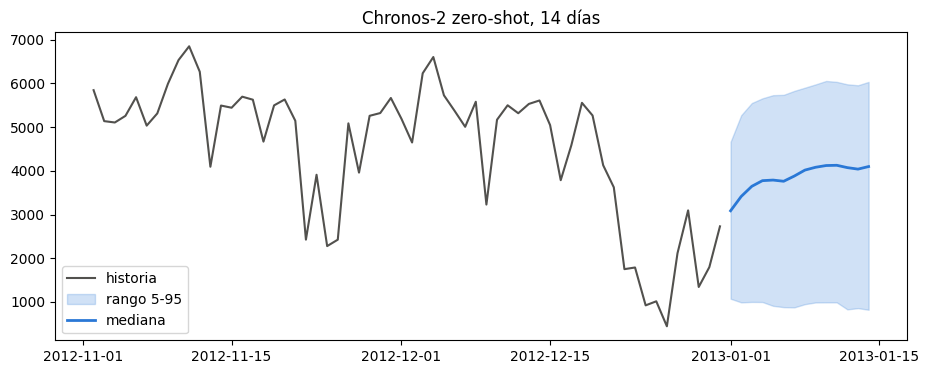

In [ ]:
pred["timestamp"] = pd.to_datetime(pred["timestamp"])
x = pred.timestamp.values
ultimos = df.tail(60)

plt.figure(figsize=(11, 4))
plt.plot(ultimos.timestamp.values, ultimos.target.values, color="#52514e", label="historia")
plt.fill_between(x, pred["0.05"], pred["0.95"], color="#2a78d6", alpha=.22, label="rango 5-95")
plt.plot(x, pred["0.5"], color="#2a78d6", lw=2, label="mediana")
plt.legend(); plt.title("Chronos-2 zero-shot, 14 días");


## 5. Varias series de una vez

Si la tabla tiene más de un `item_id`, las pronostica todas en una llamada.
No hace falta un loop.

In [ ]:
panel = pd.concat([
    raw.rename(columns={"dteday":"timestamp","casual":"target"}).assign(item_id="casuales"),
    raw.rename(columns={"dteday":"timestamp","registered":"target"}).assign(item_id="registrados"),
])[["item_id", "timestamp", "target"]]

pred_panel = pipe.predict_df(panel, prediction_length=14)
pred_panel.groupby("item_id").head(2)[["item_id", "timestamp", "0.5"]].round(0)

,item_id,timestamp,0.5
0,casuales,2013-01-01,324.0
1,casuales,2013-01-02,322.0
14,registrados,2013-01-01,2825.0
15,registrados,2013-01-02,3186.0


### `cross_learning` — que las series se miren entre sí

Por defecto cada serie se pronostica por separado. Con `cross_learning=True`,
el modelo mira todas las series del lote a la vez y comparte información entre ellas.

Sirve cuando las series están relacionadas y cada una tiene poca historia.
**No siempre mejora**, hay que probarlo.

In [ ]:
pred_cl = pipe.predict_df(panel, prediction_length=14, cross_learning=True)
pred_cl.groupby("item_id").head(2)[["item_id", "timestamp", "0.5"]].round(0)

,item_id,timestamp,0.5
0,casuales,2013-01-01,324.0
1,casuales,2013-01-02,322.0
14,registrados,2013-01-01,2880.0
15,registrados,2013-01-02,3346.0



## 6. Covariables futuras conocidas

Esto es lo que Chronos-2 agrega sobre las versiones anteriores.

Si sabés algo del futuro, por ejemplo que el jueves es feriado, la temperatura pronosticada,
que hay una promoción, se lo podemos pasar y lo usará.

Van en un `future_df` aparte, con las mismas fechas que vamos a predecir.
Cualquier columna extra en el `df` histórico que no esté en `future_df`
se trata como covariable del pasado solamente.

In [ ]:
H = 14

hist = (raw.rename(columns={"dteday":"timestamp","cnt":"target"})
           .assign(item_id="bicis")[["item_id","timestamp","target","temp","workingday"]])

pasado = hist.iloc[:-H] # historia + covariables
futuro = hist.iloc[-H:][["item_id","timestamp","temp","workingday"]]   # solo covariables

pred_cov = pipe.predict_df(pasado, future_df=futuro, prediction_length=H)
pred_cov[["timestamp", "0.1", "0.5", "0.9"]].round(0).head()

,timestamp,0.1,0.5,0.9
0,2012-12-18,3830.0,5002.0,5678.0
1,2012-12-19,4091.0,5273.0,5948.0
2,2012-12-20,3960.0,5279.0,6006.0
3,2012-12-21,3866.0,5274.0,6077.0
4,2012-12-22,3116.0,4731.0,5779.0



## 7. Multivariado: varios targets a la vez

Si le pasamos una lista en `target`, modela las series juntas, no por separado.
Sirve cuando se mueven de forma relacionada.

In [ ]:
multi = (raw.rename(columns={"dteday":"timestamp"})
            .assign(item_id="bicis")[["item_id","timestamp","casual","registered"]])

pred_multi = pipe.predict_df(multi, prediction_length=14, target=["casual", "registered"])
pred_multi.groupby("target_name").head(2)[["target_name","timestamp","0.5"]].round(0)

,target_name,timestamp,0.5
0,casual,2013-01-01,324.0
1,casual,2013-01-02,322.0
14,registered,2013-01-01,2880.0
15,registered,2013-01-02,3346.0



## 8. Argumentos

```python
pipe.predict_df(
    df, # tabla en formato largo
    future_df = None, # covariables futuras conocidas
    prediction_length = None, # cuántos pasos adelante
    quantile_levels = [0.1 ... 0.9],
    target = "target",  # str, o lista para multivariado
    id_column = "item_id", # ojo: no es "id"
    timestamp_column = "timestamp",
    context_length = None, # cuánta historia mira (default del modelo)
    cross_learning = False, # que las series se miren entre sí
    batch_size = 256,
)
```

**Salida:** una fila por (serie × paso), con las columnas
`item_id`, `timestamp`, `target_name`, `predictions`, y una por cada cuantil
—nombradas con el número como texto: `"0.1"`, `"0.5"`, `"0.9"`.


## 9. Puntos importantes

1. `id_column` por defecto es `"item_id"`, no `"id"`.

2. Las columnas de cuantiles son texto, no números.
Se accede con `pred["0.9"]`, no `pred[0.9]`.

3. Los timestamps tienen que ser regulares.
Sin huecos, misma frecuencia en todas las series. Si faltan días, los rellenamos antes.

4. Zero-shot no quiere decir "siempre mejor".
Es un baseline muy fuerte. En una serie con mucha historia propia y
patrones muy específicos, un modelo entrenado a medida le puede ganar.
Lo podemos usar como punto de partida, no como punto final.

5. Que devuelva cuantiles no quiere decir que estén bien calibrados.
Hay que verificarlo.